# INFOSCI 301 Week 4 Spatiotemporal and Human Centered Intelligence Studio

**Real data:** a reproducible NASA EONET v3 snapshot of natural-event metadata.  
**Question:** How should space, time, uncertainty, and human context be represented so that a user can act without mistaking a map for complete reality?  
**Final-project addition:** one spatial or temporal design decision, one output, one human-centered safeguard, and one next test.

The core route uses GeoPandas, Cartopy, Plotly, Folium, pydeck, Datashader, H3, PySAL, MovingPandas, GeoViews, xarray, and rasterio/rioxarray. Optional OSMnx and contextily cells include safe fallbacks because live map services can fail.

## Definition of done

1. Name the phenomenon, intended user, decision, spatial unit, time unit, and uncertainty.
2. Audit coordinate reference system, temporal coverage, missingness, provenance, and privacy.
3. Compare a geographic view with an aggregate or temporal view.
4. Produce one static and one interactive output.
5. State who or what is absent from the data, then name the Week 5 MVP addition and Week 6 user task.

In [1]:
import importlib.util, subprocess, sys
requirements = {
    "pandas":"pandas>=2.2", "numpy":"numpy>=1.26", "matplotlib":"matplotlib>=3.8", "plotly":"plotly>=5.22",
    "geopandas":"geopandas>=1.0", "shapely":"shapely>=2.0", "pyproj":"pyproj>=3.6", "cartopy":"cartopy>=0.23",
    "folium":"folium>=0.17", "pydeck":"pydeck>=0.9", "datashader":"datashader>=0.16",
    "holoviews":"holoviews>=1.19", "hvplot":"hvplot>=0.11", "geoviews":"geoviews>=1.13",
    "h3":"h3>=4.1", "libpysal":"libpysal>=4.12", "esda":"esda>=2.6", "movingpandas":"movingpandas>=0.21",
    "xarray":"xarray>=2024.7", "rasterio":"rasterio>=1.4", "rioxarray":"rioxarray>=0.18",
    "osmnx":"osmnx>=2.0", "contextily":"contextily>=1.6", "geodatasets":"geodatasets>=2024.8",
    "geopy":"geopy>=2.4", "branca":"branca>=0.8"
}
missing = [pkg for module, pkg in requirements.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print(f"Environment ready. Installed {len(missing)} missing package(s).")

Environment ready. Installed 0 missing package(s).


In [2]:
from pathlib import Path
import base64, gzip, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
import plotly.express as px
from IPython.display import HTML, display
warnings.filterwarnings("ignore")

OUTPUT = Path("outputs")
OUTPUT.mkdir(exist_ok=True)
NAVY, TEAL, PURPLE, GOLD, CORAL = "#173F4A", "#21747A", "#6A5983", "#C59A43", "#C76D5A"
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.titlesize": 12})

In [3]:
EONET_SNAPSHOT_B64 = "H4sIABwlqGoC/92dbXNbt7HHvwrHr9oZCcbiGX4nP6S2G7ue2tN0cu+dzrHESGwoUuFDEqXT7949R25F7OFCpEuuLjnNtKnlpv79D7D472IB/M8/ngx/Hk4WfxtdPHn25NWf3r/69DfjTEhPTp4sRovxEH/1u9H44ofRbDgYTQbvm+vR51EzAG0hW4e/67xZDC+ns9uV3zjHX77AX8ZfMtqEU51PAT5BfqY1/vU9/nQ8nVyOFssL/C0QlDfeRsje6+jxZ83iy49OISsDOTmfs882njyZD39aDifn+DON/2W6nLV/++T92cezQfdnH/xs8Z9+R7ScjfFnV4vFzfzZ06fD6WS4UJfzH87VpJk36nL689PmZvT0Z/u0++3zp6vw/zxhdMkb6eJ3o0vyVudoXHIhUl006GSCB2d1ktIls7okbrycLeeLWTP+tzI+7kIZY1WyCZyLAZItlYkqomzO6xBjAiFlEj9iEjdins+a30bjL7KkHchy6nDEGAjOQ/TakpkEyoagQwo4j8BI6cKPmKwZXb5vrv8zkZzeXBfN6YKjJRhncZ7EqH1vuJgcrHPBGAdOSBZkZ2WBTYZL3oEsp14rQFXAgg8BQqFLVjbjSPE2JfxPMV2A18VsoovZiS6gQrQpOGucg1yOF6sshOgNJI2DRkoXw+ri/GaBFzZfknSuBd6Qo7OgQzaFMEYrjDkYXyzElKRWaqRnhQkbChN2JEy2OmaTMYoADTEZ47E3GgOw1IKE9KwwkRNmcjkd36mSct6BKjgmXE5ZJ28sClCqgq4PlcoYmLVY3EV0VpW0wXKk9Q5UsYCrtNU62uAdHSta4QAKLgNADFlKFt69ONa9TBfzX5rJv4dL2sVwcQojrsaVGONuLIVpA4812ruIFrK1NjLC8PYl6k0SAaN3M41wAtlsog+5NfurAybhGu7QaEGKJkolApH3LxE20gV2EXTRpNhscbYYgwJRXbwJoLVLaG6kJlKs+Be7id2FHcWXjDmosQmni6fxJUVcuwNAO6Sk7ItlZLFJr06jF7fnyDEcvGtmo2GpxEf8H6NeHxfT2fU6NeCTDuvdHKbJqogl4JTMKtzR7RvcfOqo14JnVZhX8KqYCHDg4GAY8DbXLcAxL14FNwcNbvmhjtmJK8CTKpy4PWhwxw/1u6G9Ap5V4RHcgYPzQz2qQMCLOe4PGtxXhnou57iBMqqHAweHxICjGwwEvPji8aDBAz/UjSFf3KrCwKSDBo/8UDckqmOeVNRv84GD80PdlVEd/3tRcYPDtm6pMtZj6VmNL9czeBTvFu1qNeDTbHozOm/Gd4CDVxfTZTO72Nq22/USZFBFpmuSkqm2dpSSAjBV6GyIAFlpGfcuLAB4RgBL4n1WTsbFCwtggBHAtV+8ECA7L+PnRSUwfBRwpdmxWsrXSwvARQFfjgEUIMn4e2EB2ChABYDS9YVjEYCNAl4ZIkCQ8fuiAlg+BnhVNL9YU9rfdDQCcDEgKE8E8DL+vyJAgNVC/+vlbIYCoA/+I/rgSbMFejo1lRQAoGQHEv/2ZwNbQAH2VGEnM/+uuifhAIXYc7WuZUjt2sqYPxl2qyvJH5QBD7WwMq5PiB0q7K7O7g6a/S7fYdkTiXWpzPj8obMbvsaFrsYQdi9j84TYK7s2lsZ5snkRD53dVdgTKfFpqaKuEHtlC8OZ8rsbkKrrCrEHfsPO2TLOGyh9HehDh48VeJLRGEtKe4/k7Cyf0jxvJpen3+K/bevsmdEPwZCt6qCylLG3shIwCz4Eulsfyy1MOCIJEiOBI0tfLIsb5lgkSPxEIMFArmdDXAJ2IpACh1z3hrwE3ESIZLNDl6PAH4sEmVsWWwnKDS8jVemVl4CLBYmMAlcag3g8ErCxIBFv5OUSAkkJrK5NhEz2fKJUXiAtQdgsHFrS6wP6eDRgZwLpabSkbxkeyR+6ysbHollunSDwsyCSFdFJJQhOjj5sFgNobQCOgr7ihlItQTZHQJ9qI9/XXIA9DvrAJgOp1vTnjoKeHfm+Z3+SVB4gRV9JATz59qGM+eEo6CsLviO+T8z9C9LzI1/XXG86fPqa5yf7nkifpTy/HH2lAESbvEDM7gvip82WPAvl0IdHcXsmBR7/7XI8mm439euHeTI5oim0GdBCivHz3S6ZHFGNUr3esvxsp1MqJwAtAJtH4dee538zH47Hw+0EsJXzi9CbAEJnlFtKQQHYCGDIOUZ61OdIBOCnAOl0hyC1EyYpQO0ILznsRQ9t2yMRgF8EQm8j0MgkvsICpE3PMieps8ySAtRtUKiVPMORCMB3QOpezTfJZMCSAlTaoowh5z5JIpSORYDAC0Dr3kJnHWQFqJ159mQX3AulwpIKVLrj7s46FwokoWy4qkAlG3o3/XFLfuBHgKM+wKoolQsEIfzKrUWO7P0gfpLKBOTw2SXQ5V4iJJUKS+Jzg9/rHr5YFiCFX6kDeHrczZfrvzsOfG7194aEPoLvjwKfH/y+jh+OAL9SAfCkDH53/lHG/Qvis4M/9q7rs1LeXw6fXfh87oU+J+X8pfA9P/iD6eFHMd8vyM+N/mAJfyANT4/k+yLP/76ZzZptbT/X9qJTr/QRpFx/lMPntkB16t1qB1KuXwyfzXpa/OpRQHMc+Nz+P72i15DuB3sM+Lb29XXt8Ic7Evyw8dcPUq5fEJ8NfbTZVbDqL4bv+MEfe5seVsr1C+KzoY+cdLjbA5Jx/WL4vvb16dE/K+X6JfHDZus+kDsOQR8HPxv7+jueWsz1c/wmmyLrub25mk4ng48N/hHHW5ED3+rsyclnqetNO7h9cxv+ZJfXpMoBQo8SyIDzGY6jgZ6c9jeHDc67W2d6N7XLHGeRAeeXdmt753iyiK2XAeejuqGGPpZ7WP6wwflTe4YEdRRCxsrLgPM3OADNYWKZwcaDBq+c26CNu+0bZiL2XQacr1eC7hl3mXK9APjdNX1McIPQW86ELLsMOb+Q4yR35FSuUGNOjdwHs+Y5htfD2aSZbGfWbfV6wkRaU2X68zs8AXJ2W87SkwlJqDAvRs7txlvTO5Qj84qYDHllI773zUmqYg+ePGxKHoRuopIi5+e5KfcgwAsV4cXI01eSh8Mmr/Qc9CJcKOd5PHhydp5bUncNUrZdiJyf56537ybI+HYp8sRfs+zIPBe6craODrVa++Tyx2ZrF8sV4ug2M1nc9skPkvxMykpbq2lZCo6EnyvSeCDfPwndqiTNz2Tunlw5bJLQuwqi/PxOu7c9fjFzK8ofWP5Yq876I+Fn5z89WpaELlit81fuVPy2GW9JXzlaQq/bByd0rqpjlMGvpLYu9lJbI7X6SeFXfK93j1fNkcKvHKoMuvfORpJa+6TwK+/phlA/We+OAD/zoS/q3msbWWrlE8LnW+sRn27SBaFzVYL4lSOlkSx8VqrDUhC/Us2O9A1ZUw7+dAT4lYUvBnKrJDlRm48Av3KfQiQdltaTfrMjsH38bbrIT66Ws0nqFvE6v+b5X8xG88X0czPe2vozbwg7S66XDHLOX8tKwL0i7Ejtx0Y59y8qAf+MrqWRIAndsCYvATcRLL1olDTt2MeQwNbumQT/3XbwlTclqAmOUj0clr1kcufw7A27+rFq35LwiYU3NXhz+PDA3yytSWtmkprzLDzk5FefT/8wWkwng4vhYNwMvsE/y6QZzYcngz8Pl5MR/uB338wa/KP+vlTkL9PxeTOZDntqOBSEU6O9YUMXcpy2R22dyMsid9iMIrk4aX/2YzMZfCE8Gbxtbug+KEtvK/TgnNJQdC+iNbJJiD7rwNOvnjh6h/+c2+ae/z3OjFlzuWw21MBUdkFPEyb/ISV6BiU5MRUiq4JZNQOvh83s4l6Es+V8MWvGoy1EYINCtMqX4+DUWwU6CElgNC/B6nbIt80cv/y9Bi+uRvSiuQo/PxFO28eFSn6DEyFK4TO7IRChyAvPrj/Pbq/v8f/STJbNYrmhAFCLBAHTwGJNPG33A0TaAe4oWQHcDgMBdG+O//8MBB3qehWCyavh8P1tc70cN5ej2YoUL/88eIEw002U8JgZVh4kNlmRoaCcTiIidKScCLocCpNmZSp8aG6WzeD98JfBH5ajybDZUAaoneVwXmlbpAinuF5KCaH50aBXl4XnzWw2nAzezMfNZGV5eDO5GG2uAv8GT7Yq+XJSGGWimAqaV6F4m7u5HY/w23/+PLrX4NXiaoQ2egsZumYZY/syOEwWIQC5iNIDgJQQwAuxehfrBxwG51f/u9T6Bzs5/TBcDGfT5itWzE6Pim2KWvlQOmfrFZp8KT2Ym1nBJ1idHm+mi+lXOGf/5dQPGxswS0j0pFf0MqOhQ2TorVldKl4Or2+mRVDA/4/5pjOi/jiXRodogIZHkPGMHScrQSji4yUuFf/tSlF/oQ/TSMhFPeUUzYSQf+x410phMblYUeIjmoZf8OuvjIPBu6j84FUzW1z9tGzo9W33v17IAamdHO3pT9TCrDsYllVyuhwaWkFMItOjo16vh7OrdpqOhBUdBijLu43FMN2GW3zmHObPa467RxIog9JBZAHtgBkpzGrF5U/Nr815czJ4N/x1dD5dFQIHiNlCCAifcPm0+ZkzdMXIUQVv6ZsmLsgIYZhKi7VFxf3jdLm4GvxxOiuHg1duw+EQu3XTf9IeffS6I+ForiPZfNJBJNHqUBkRivrbm1kzKSeD3Yq+a7rriq/URXmVfSC7z1kL0XPFNmvS6pr5YTn8PL6fC+8QH7YOkbENkfx1L6c5KYxT5CCll6m8dbyMEjEUddi/479ay7SiRvpaNSrlF0wyItDrTqViZMu8Xg0oEq23o+VvV83ocrrsbPSk+RoZUq0Io9E/ZQ/koXNjZXLODpcTYjXX+ivC47CYXO5Jh4QrZkpFmHBOuWCdkAxcc3I0rrBTs9FlMx3g3BhNLtBjtuYS06vRzQ26ifnXqGK6/UpmdBivbDFHshIZFx32ekFCgkKQ62Yxa1bt5T3ryeDl8Hx4/Xk4GyBr2EySUC9UZTTZ5e4NZqAyJrNDXysKGt+0WrMdD39tJheI/by5PRnc+YuzH2aj82bwcjlf3G3hlXJ0v95Wc143vw2JxwLd3abFlXGVs967kKIvq9lJhaSzy9Ek/HkOIlOpk4IxHG7Vid8LcdLdUTEanM2az6PmKTqRnzbVJnbasEsu+vBgQvYWjCfdjz4YEzDyapezc1bGjTi25l3uBL85H+KkuRycGfuW7gE3nRLfth4Nf1u/2g3801IOVCyrvN6oJJO8R34n2CcP/z28b4eCZas3besPSdcR3kgVbzzsGx669mcOHvMw8uVBOZFL96rwLtv18G+2gm99dwU+qOzoRqeW+fAt4P7ZU+3DA9BRXxap4LDhK0/pIbwH+uGNyKXqEvAY7zSfbTpddnu27F7kChch9vpC52Mv1oscdBWCrzwghR/ekYVOq2wlzvoIwddWefKKfMtuRK5yEWGH2p1NyG7KhhaXVQwSx3wegHdr4J8b83aHizwazO5Dr9C3R76S1DLv9k9fezQ2OmUcpfdJap3fN3093EP0ZX9rCw9Rap3fOzxU6iHd4a5YupyoVQhSK70AvalN+6hspvQQpZZ6Cfq0DX3IxOj4Q6Y3p7pyd1lMKiZKD1KL/X7h7zoXcx2efPqkvJda7QXoqxE/qdwb+NpInOkVouebFO8OtBr67YORONJbp09pvc39w7ZeR7taVk/g2751ob6blnDv8LV6TlbOU3jrhXze3uHrJY21JVzvhXze/uGrPs8mWs9B9izk8iTYa5ltUpB7hTwpkycBX6/dm14JNwtZPBH2VPvwwfZqWUbI4tXg83r417td6CD1Yr1URSPl/cPXNy5yb8qXjYNw2PCVck5bwu3tWNkgtdDtG/6BjQtQJtO9ymClVjoB+Epi09ave/DeSa10LLwuOmZX4L/Zbtin6krnle85+yQU8DTXKAvOa6Y54+V28LEa8DC8EfighM4hdoR7h7fVL+9s/cvDIcPXWh+7ber+bqUTifYy8HV3m30v2keRaC8En2rDnnam6C7FFYj2dfi4Hv7VbgMe2bDDgCd0mq4j3Dt8LeDdlaxW4b1gwNs7fD3gOXrzQnsttZUKeALwtVqG6xWxLGnPsIcNb6rDPvVqGUK7dULw1YDnfT2x8YcMX2/C7Ac8TdozwmPAm+TXb9i82Xqpq+xSh17lOrZ3LMisdS3inumr4b6jj5TegMxiJ0Jf3aPXypaJXTRKy3SnSNBXa5jtxdO0PwOIxbWHTf9AU1qIlD4amfVu//QPt2WRnYu2LyvILHgC9A92JoGjnUkuyqx4MvSp2qIAgTZolOt9PGT6BzqT8pqePBB5XnD/9A9cqtbBewrvg0h3igQ8fvp6Z5LvNSRqkevmhehNnZ5cn4bT3huR2+Zr+NYGJsl5sd1672rvTLR3a1ta0hK6UbEj3DO8r92laB2N+AgfZXZsheBztaTVr+eJeHwZ9tqepVO9ap6RqeDX2dc1qLy04Wx3Mz4FWtIJocv2ZCZ84tnzevbnO2WPjrLLBTtuq9oEYMb8luxQq987rVLsBbssAt8R7hm+6nEQnm5bxW7zWiDSy8BX6vcIT07ZIXx5AYk5bHhTbT/2BF7oAV0Rdlu7/dT2jhy0ox5EajkVeG3Arjf22zRiui9vZ7LG3kRFHk2IRslc5HeHuE96/8A14YDjXpM6niMNeXDI9Laa0rrUO1zqSSOqOWR6V61go5tNoUcv8n6KCH3V20O7uNneyE8iUU+CPlTreAF6Uc8Sm+cPmb7aoAPB9KKe6WraAhVsCfoHdi11b+S3F4CLVLBl6Gv1exz5yfROlYNIBVuCPj808nsbV2Vqmw8Yvn7Yqv300DtWXZ4uhcP1eg+WsH1v7yakrrgnUcLm8a0NZvWe3qvbxfRm3Ex+bN9Nez6eTq9PBp+a+XUzGSD/0/aK8++HTftASCnOd/i3s8GL6Xg661/jzK+FgGPABm+ss2Rzx1nlbMjB418GkjFC91qbJ//8v38B0C4lOLoQAQA="
records = json.loads(gzip.decompress(base64.b64decode(EONET_SNAPSHOT_B64)).decode("utf-8"))
events = pd.DataFrame(records)
events["date"] = pd.to_datetime(events["date"], utc=True)
events["month"] = events["date"].dt.to_period("M").astype(str)
events["year"] = events["date"].dt.year
gdf = gpd.GeoDataFrame(events, geometry=gpd.points_from_xy(events.longitude, events.latitude), crs="EPSG:4326")
print({"geometry_records": len(gdf), "events": gdf.event_id.nunique(), "categories": gdf.category.nunique(),
       "start": str(gdf.date.min()), "end": str(gdf.date.max()), "crs": str(gdf.crs)})
display(gdf[["event_id", "title", "category", "date", "longitude", "latitude"]].head())

{'geometry_records': 272, 'events': 74, 'categories': 7, 'start': '2016-12-07 00:00:00+00:00', 'end': '2026-09-11 19:00:00+00:00', 'crs': 'EPSG:4326'}


,event_id,title,category,date,longitude,latitude
0,EONET_24268,Wildfire in Namibia 1031934,Wildfires,2026-09-11 19:00:00+00:00,16.525372,-19.219846
1,EONET_24269,Wildfire in Namibia 1031935,Wildfires,2026-09-11 19:00:00+00:00,16.853097,-19.010827
2,EONET_24288,Wildfire in Australia 1031957,Wildfires,2026-09-11 19:00:00+00:00,123.838145,-17.785345
3,EONET_24289,Wildfire in Brazil 1031958,Wildfires,2026-09-11 19:00:00+00:00,-46.821645,-11.366069
4,EONET_24290,Wildfire in Zambia 1031940,Wildfires,2026-09-10 19:00:00+00:00,23.624331,-17.296345


## Part A  Audit before mapping

EONET is a curated event-metadata service. A point can mark a source-provided location, not the complete footprint of a hazard. Counts depend on source coverage and curation. The map therefore supports exploration of recorded events, not estimates of population exposure, severity, or community need.

In [4]:
audit = pd.DataFrame({
    "check": ["Spatial unit", "Temporal unit", "Coordinate system", "Missingness", "Coverage", "Human context"],
    "answer": [
        "Event geometry point; not necessarily full event footprint",
        "Source observation date; events may have repeated positions",
        str(gdf.crs),
        f"Missing coordinates: {gdf.geometry.isna().sum()}; missing dates: {gdf.date.isna().sum()}",
        f"Bundled snapshot: {gdf.date.min().date()} to {gdf.date.max().date()}",
        "No direct record of affected people, lived experience, exposure, or response capacity",
    ],
})
audit

,check,answer
0,Spatial unit,Event geometry point; not necessarily full eve...
1,Temporal unit,Source observation date; events may have repea...
2,Coordinate system,EPSG:4326
3,Missingness,Missing coordinates: 0; missing dates: 0
4,Coverage,Bundled snapshot: 2016-12-07 to 2026-09-11
5,Human context,"No direct record of affected people, lived exp..."


## Part B  Geographic and projected views

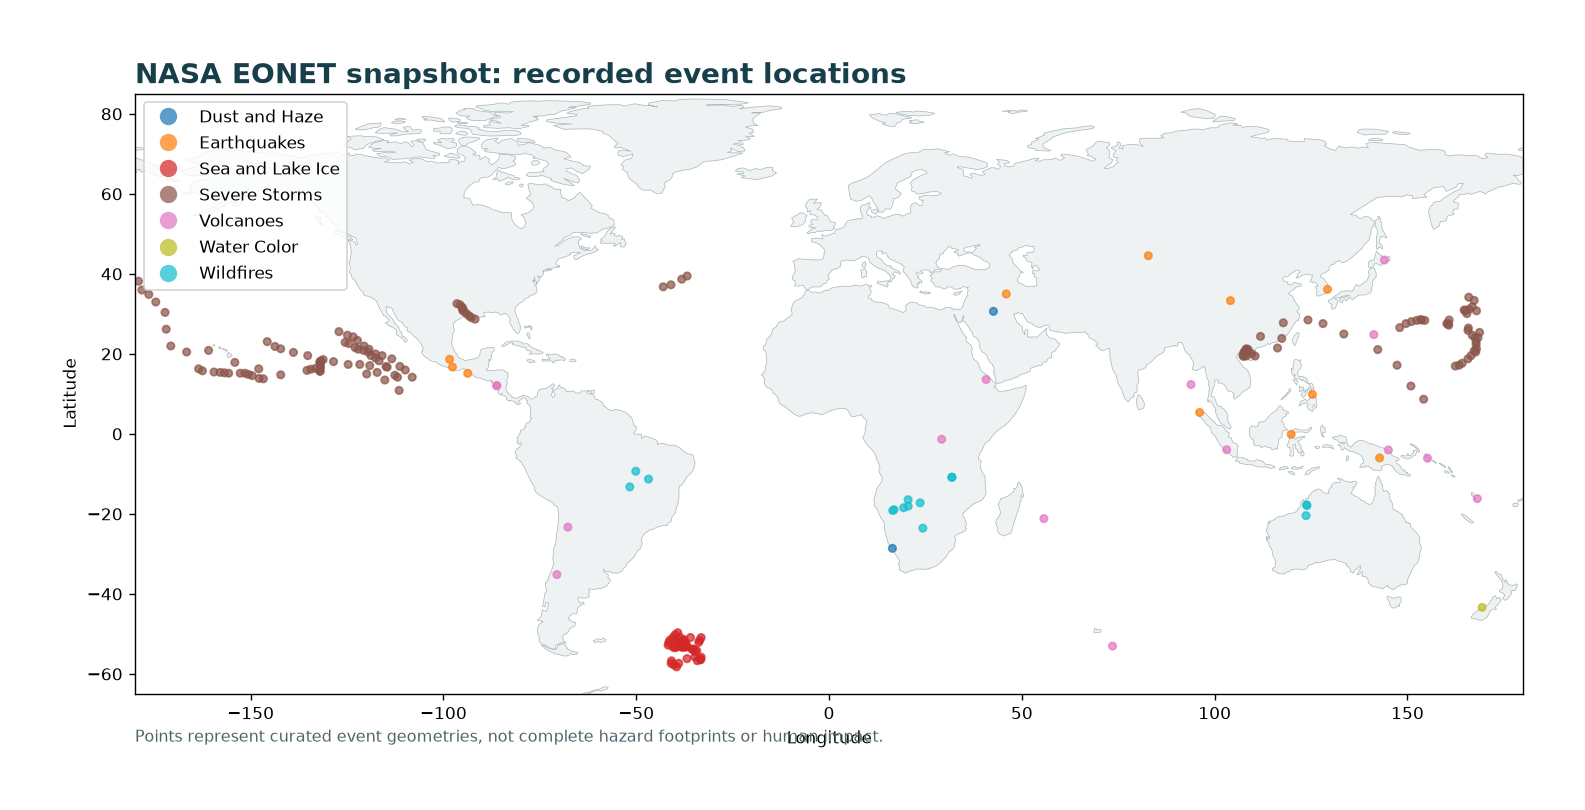

In [5]:
import geodatasets
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))
fig, ax = plt.subplots(figsize=(12, 6.5))
world.plot(ax=ax, color="#EEF2F3", edgecolor="#A8B5B9", linewidth=.4)
category_order = list(gdf.category.value_counts().head(7).index)
plot_gdf = gdf[gdf.category.isin(category_order)].copy()
plot_gdf.plot(ax=ax, column="category", categorical=True, legend=True, cmap="tab10", markersize=18, alpha=.72)
ax.set_xlim(-180, 180); ax.set_ylim(-65, 85)
ax.set_title("NASA EONET snapshot: recorded event locations", loc="left", fontsize=16, fontweight="bold", color=NAVY)
ax.text(0, -0.08, "Points represent curated event geometries, not complete hazard footprints or human impact.", transform=ax.transAxes, fontsize=9, color="#4F646B")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
fig.tight_layout()
fig.savefig(OUTPUT / "eonet_geopandas_map.png", bbox_inches="tight")
plt.show()

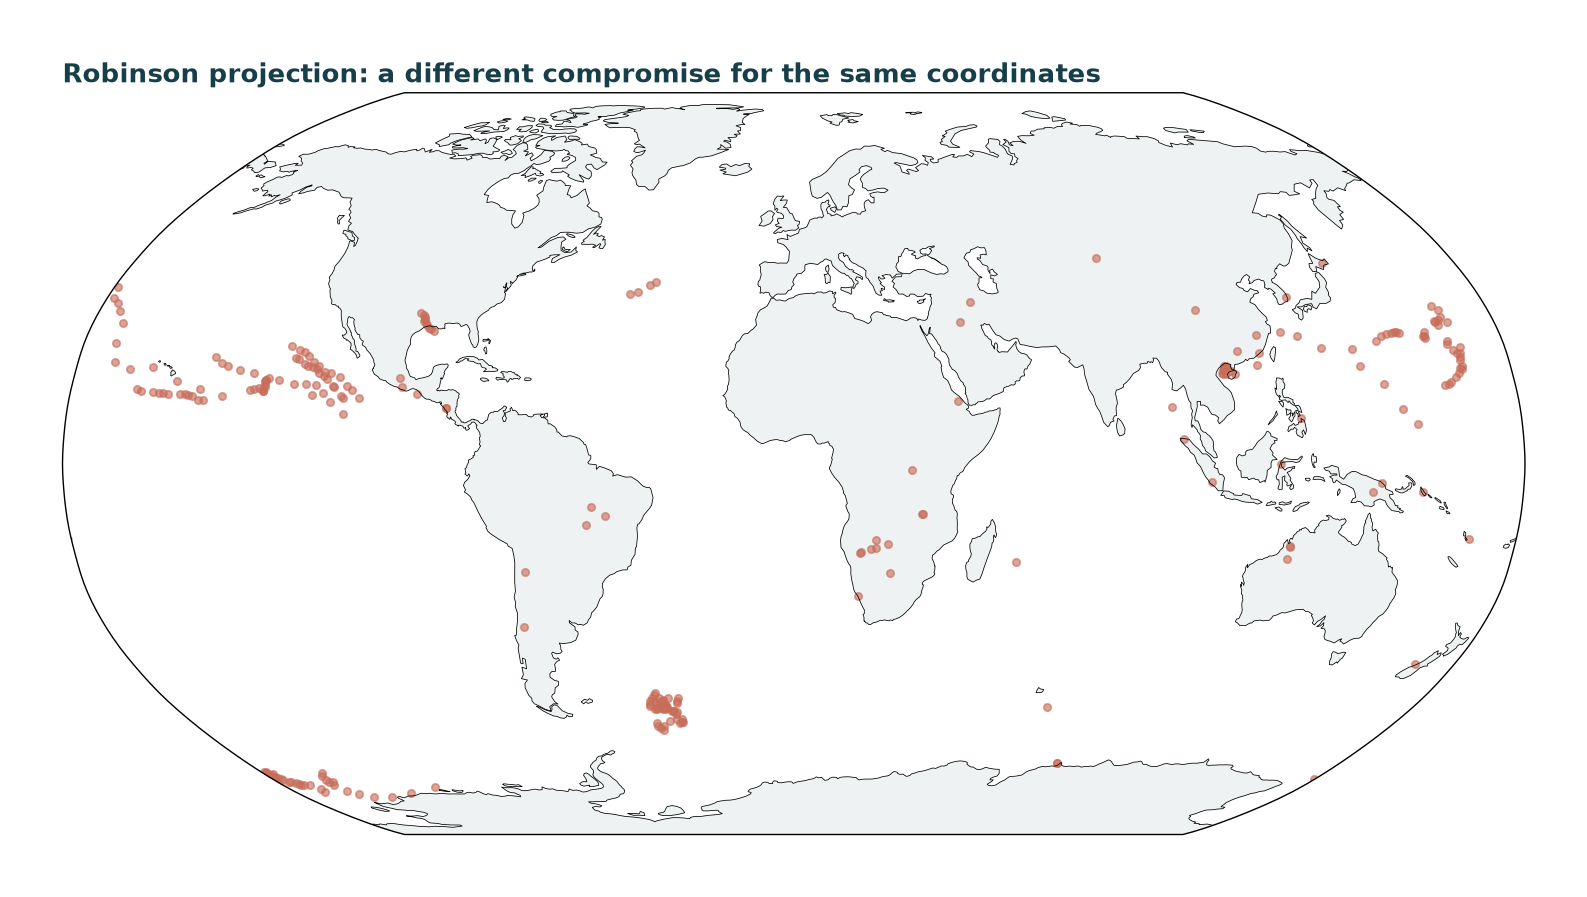

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
fig = plt.figure(figsize=(12, 6.5))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
try:
    ax.add_feature(cfeature.LAND, facecolor="#EEF2F3"); ax.add_feature(cfeature.COASTLINE, linewidth=.45)
except Exception:
    pass
ax.scatter(plot_gdf.longitude, plot_gdf.latitude, transform=ccrs.PlateCarree(), s=18, c=CORAL, alpha=.62)
ax.set_title("Robinson projection: a different compromise for the same coordinates", loc="left", fontsize=15, fontweight="bold", color=NAVY)
fig.tight_layout()
fig.savefig(OUTPUT / "eonet_cartopy_robinson.png", bbox_inches="tight")
plt.show()

**Projection check.** Coordinate transforms change geometry. Choose a projection for the user task and extent; do not treat Web Mercator or any global projection as neutral.

## Part C  Time and interaction

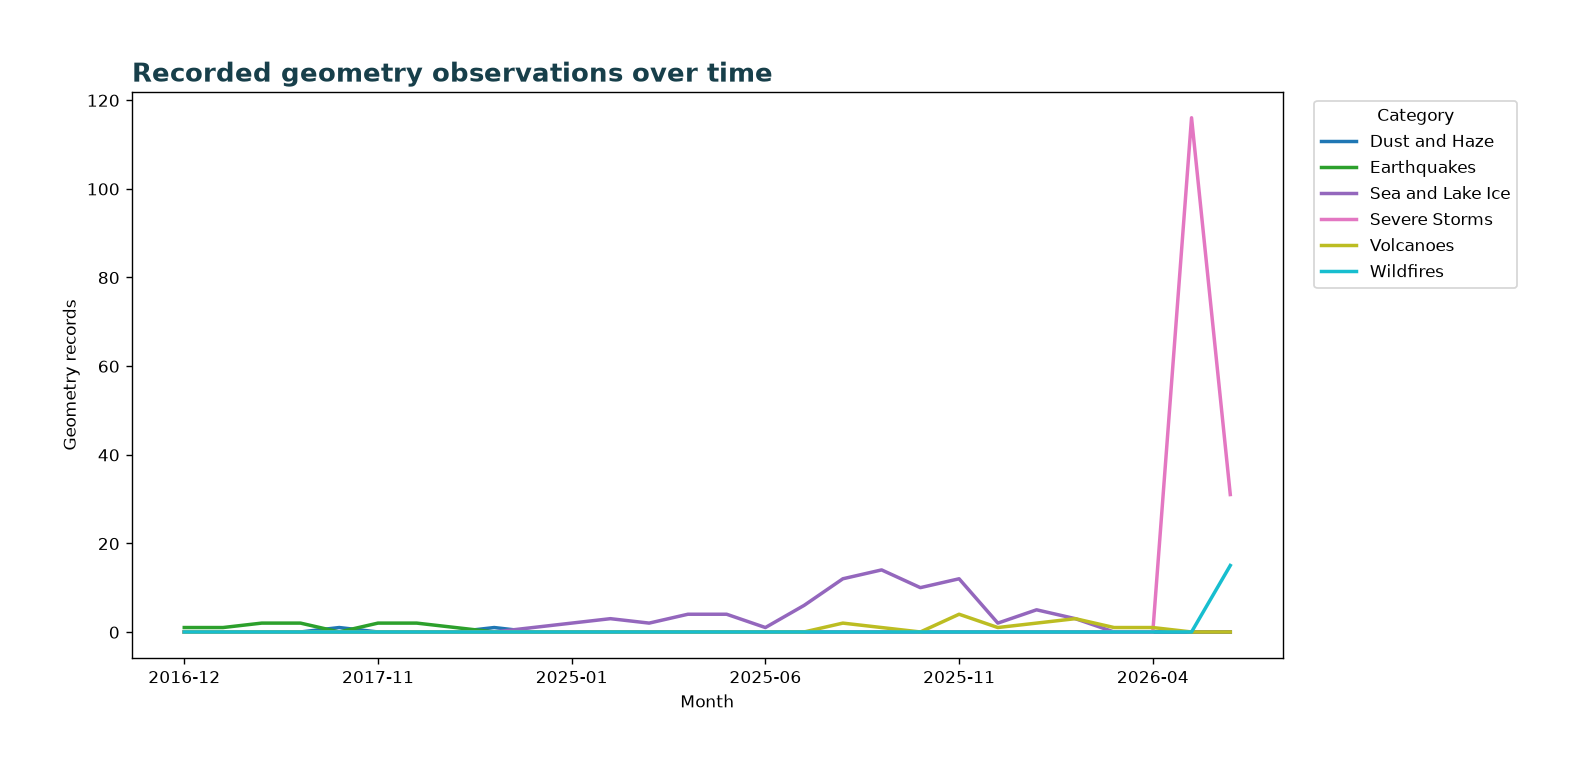

In [7]:
monthly = gdf.groupby(["month", "category"], as_index=False).size()
top_categories = gdf.category.value_counts().head(6).index
monthly_top = monthly[monthly.category.isin(top_categories)]
pivot = monthly_top.pivot(index="month", columns="category", values="size").fillna(0)
ax = pivot.plot(figsize=(12, 5.5), linewidth=2, colormap="tab10")
ax.set_title("Recorded geometry observations over time", loc="left", fontsize=15, fontweight="bold", color=NAVY)
ax.set_xlabel("Month"); ax.set_ylabel("Geometry records")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT / "eonet_monthly_timeline.png", bbox_inches="tight")
plt.show()

In [8]:
# Plotly uses scatter_geo so no access token is required.
animation = gdf.sort_values("month").copy()
animation["label"] = animation["title"].str.slice(0, 70)
fig = px.scatter_geo(animation, lat="latitude", lon="longitude", color="category", animation_frame="month",
                     hover_name="label", projection="natural earth", opacity=.72, height=620,
                     title="Explore event locations by month")
fig.update_traces(marker=dict(size=6))
fig.write_html(OUTPUT / "eonet_plotly_animation.html", include_plotlyjs="cdn")
fig.show()

Figure({
    'data': [{'geo': 'geo',
              'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ongitude=%{lon}<extra></extra>'),
              'hovertext': array(['Sumatra, Indonesia Earthquake, December 2016'], dtype=object),
              'lat': {'bdata': 'ObTIdr4fFUA=', 'dtype': 'f8'},
              'legendgroup': 'Earthquakes',
              'lon': {'bdata': '9P3UeOkGWEA=', 'dtype': 'f8'},
              'marker': {'color': '#636efa', 'opacity': 0.72, 'size': 6, 'symbol': 'circle'},
              'mode': 'markers',
              'name': 'Earthquakes',
              'showlegend': True,
              'type': 'scattergeo'}],
    'frames': [{'data': [{'geo': 'geo',
                          'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ongitude=%{lon}<extra></extra>'),
                          'hovertext': array(['Sumatra, Indonesia Earthquake, December 2016'], dtype=object),
                          'lat': {'bdata': 'ObTIdr4fFUA=', 'dtype': 'f8'},
                          'legendgroup': 'Earthquakes',
                          'lon': {'bdata': '9P3UeOkGWEA=', 'dtype': 'f8'},
                          'marker': {'color': '#636efa', 'opacity': 0.72, 'symbol': 'circle'},
                          'mode': 'markers',
                          'name': 'Earthquakes',
                          'showlegend': True,
                          'type': 'scattergeo'}],
                'name': '2016-12'},
               {'data': [{'geo': 'geo',
                          'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ongitude=%{lon}<extra></extra>'),
                          'hovertext': array(['Surigao , Mindanao, Philippines Earthquake'], dtype=object),
                          'lat': {'bdata': 'mpmZmZmZI0A=', 'dtype': 'f8'},
                          'legendgroup': 'Earthquakes',
                          'lon': {'bdata': 'ZmZmZmZWX0A=', 'dtype': 'f8'},
                          'marker': {'color': '#636efa', 'opacity': 0.72, 'symbol': 'circle'},
                          'mode': 'markers',
                          'name': 'Earthquakes',
                          'showlegend': True,
                          'type': 'scattergeo'}],
                'name': '2017-02'},
               {'data': [{'geo': 'geo',
                          'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ongitude=%{lon}<extra></extra>'),
                          'hovertext': array(['Xhinjiang, China Earthquake', 'Jiuzhaigou, China Earthquake'],
                                             dtype=object),
                          'lat': {'bdata': 's3vysFA7RkBa9bnaip1AQA==', 'dtype': 'f8'},
                          'legendgroup': 'Earthquakes',
                          'lon': {'bdata': 'CmgibHiyVEBgdk8eFgZaQA==', 'dtype': 'f8'},
                          'marker': {'color': '#636efa', 'opacity': 0.72, 'symbol': 'circle'},
                          'mode': 'markers',
                          'name': 'Earthquakes',
                          'showlegend': True,
                          'type': 'scattergeo'}],
                'name': '2017-08'},
               {'data': [{'geo': 'geo',
                          'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ongitude=%{lon}<extra></extra>'),
                          'hovertext': array(['Pijijiapan, Mexico M 8.1 Earthquake',
                                              'Puebla, Mexico M 7.1 Earthquake'], dtype=object),
                          'lat': {'bdata': 'iUFg5dAiLkAv3SQGgZUyQA==', 'dtype': 'f8'},
                          'legendgroup': 'Earthquakes',
                          'lon': {'bdata': '9ihcj8JtV8Coxks3iZlYwA==', 'dtype': 'f8'},
                          'marker': {'color': '#636efa', 'opacity': 0.72, 'symbol': 'circle'},
                          'mode': 'markers',
                          'name': 'Earthquakes',
                          'showlegend': True,
                          'type': 'scattergeo'}],
                'name': '2017-09'},
     

In [9]:
# Folium: layer control plus a time-aware point layer.
import folium
from folium.plugins import TimestampedGeoJson, MarkerCluster
center = [float(gdf.latitude.median()), float(gdf.longitude.median())]
fmap = folium.Map(location=center, zoom_start=2, tiles="CartoDB positron", control_scale=True)
cluster = MarkerCluster(name="Event points").add_to(fmap)
for row in gdf.drop_duplicates("event_id").head(100).itertuples():
    folium.CircleMarker([row.latitude, row.longitude], radius=4, color=TEAL, fill=True,
                        tooltip=f"{row.category}: {row.title}").add_to(cluster)
features = []
for row in gdf.sort_values("date").head(500).itertuples():
    features.append({"type":"Feature", "geometry":{"type":"Point", "coordinates":[row.longitude, row.latitude]},
                     "properties":{"time":row.date.isoformat(), "popup":row.title,
                                   "icon":"circle", "style":{"color":CORAL},
                                   "iconstyle":{"fillColor":CORAL, "fillOpacity":.7, "stroke":"true", "radius":4}}})
TimestampedGeoJson({"type":"FeatureCollection", "features":features}, period="P1M", add_last_point=True,
                   auto_play=False, loop=False, max_speed=2).add_to(fmap)
folium.LayerControl().add_to(fmap)
folium_path = OUTPUT / "eonet_folium.html"
fmap.save(str(folium_path))
display(fmap)

In [10]:
import pydeck as pdk
deck_data = gdf.drop_duplicates("event_id")[["longitude","latitude","title","category"]].copy()
layer = pdk.Layer("ScatterplotLayer", deck_data, get_position="[longitude, latitude]", get_radius=45000,
                  get_fill_color=[33,116,122,150], pickable=True)
deck = pdk.Deck(layers=[layer], initial_view_state=pdk.ViewState(latitude=10, longitude=20, zoom=0.5),
                tooltip={"text":"{category}\n{title}"}, map_style=None)
deck_path = OUTPUT / "eonet_pydeck.html"
deck.to_html(str(deck_path), notebook_display=False)
display(HTML(deck.to_html(as_string=True)))

## Part D  Aggregate, rasterize, and test spatial pattern

<xarray.Image (latitude: 360, longitude: 720)> Size: 1MB
array([[4284116423, 4286215201, 4286215201, ...,          0,          0,
                 0],
       [4286215201, 4286215201, 4286215201, ...,          0,          0,
                 0],
       [4286215201, 4286215201, 4286215201, ...,          0,          0,
                 0],
       ...,
       [         0,          0,          0, ...,          0,          0,
                 0],
       [         0,          0,          0, ...,          0,          0,
                 0],
       [         0,          0,          0, ...,          0,          0,
                 0]], shape=(360, 720), dtype=uint32)
Coordinates:
  * latitude   (latitude) float64 3kB -69.78 -69.35 -68.92 ... 83.92 84.35 84.78
  * longitude  (longitude) float64 6kB -179.8 -179.2 -178.8 ... 179.2 179.8
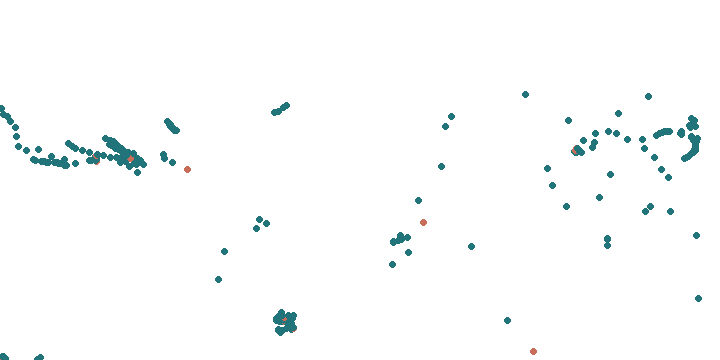

In [11]:
import datashader as ds
import datashader.transfer_functions as tf
canvas = ds.Canvas(plot_width=720, plot_height=360, x_range=(-180,180), y_range=(-70,85))
agg = canvas.points(gdf, "longitude", "latitude")
image = tf.shade(agg, cmap=[TEAL, "#4DA6A6", PURPLE, CORAL], how="eq_hist")
image = tf.spread(image, px=3, shape="circle")
export = tf.set_background(image, "#F5F8F8").to_pil()
export.save(OUTPUT / "eonet_datashader_density.png")
display(image)

In [12]:
import h3
h3_res = 2
h3_frame = gdf.copy()
h3_frame["h3_cell"] = [h3.latlng_to_cell(lat, lon, h3_res) for lat, lon in zip(h3_frame.latitude, h3_frame.longitude)]
h3_counts = h3_frame.groupby("h3_cell").size().sort_values(ascending=False).rename("records").reset_index()
h3_counts["center_lat"] = h3_counts.h3_cell.map(lambda c: h3.cell_to_latlng(c)[0])
h3_counts["center_lon"] = h3_counts.h3_cell.map(lambda c: h3.cell_to_latlng(c)[1])
display(h3_counts.head(12))

,h3_cell,records,center_lat,center_lon
0,82de9ffffffffff,14,-51.865628,-37.000564
1,82eac7fffffffff,12,-69.439039,-177.844387
2,825027fffffffff,7,17.310335,-131.001334
3,824157fffffffff,6,21.905988,108.544811
4,82496ffffffffff,5,20.020854,-119.247002
5,824147fffffffff,5,19.584166,106.674913
6,82446ffffffffff,5,30.774742,-94.876334
7,82de97fffffffff,5,-54.219423,-34.669836
8,82de87fffffffff,5,-54.117174,-39.659045
9,82de8ffffffffff,5,-51.683695,-41.629080


In [13]:
# Moran's I on an equal-angle grid; interpretation depends on the grid and neighborhood definition.
from libpysal.weights import lat2W
from esda.moran import Moran
lon_bins, lat_bins = 24, 12
counts, _, _ = np.histogram2d(gdf.latitude, gdf.longitude, bins=[lat_bins, lon_bins], range=[[-90,90],[-180,180]])
weights = lat2W(lat_bins, lon_bins, rook=False)
moran = Moran(counts.ravel(), weights, permutations=199)
pd.DataFrame({"measure":["Moran's I", "permutation p-value", "grid"],
              "value":[round(float(moran.I),3), round(float(moran.p_sim),3), f"{lat_bins} x {lon_bins}"]})

,measure,value
0,Moran's I,0.091
1,permutation p-value,0.015
2,grid,12 x 24


In [14]:
# xarray + rasterio/rioxarray: represent aggregate counts as a georeferenced raster.
import xarray as xr
import rioxarray
lon_edges = np.linspace(-180,180,lon_bins+1); lat_edges = np.linspace(-90,90,lat_bins+1)
lon_centers = (lon_edges[:-1]+lon_edges[1:])/2; lat_centers = (lat_edges[:-1]+lat_edges[1:])/2
raster = xr.DataArray(counts, coords={"y":lat_centers, "x":lon_centers}, dims=("y","x"), name="event_records")
raster = raster.rio.write_crs("EPSG:4326")
tif_path = OUTPUT / "eonet_event_count_grid.tif"
raster.rio.to_raster(tif_path)
display(raster)
print(f"GeoTIFF written: {tif_path}")

GeoTIFF written: outputs/eonet_event_count_grid.tif


<xarray.DataArray 'event_records' (y: 12, x: 24)> Size: 2kB
array([[ 0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [21.,  8.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 45.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         8.,  0.,  1.,  0.,  0.,  0.,  0.,  3.,  0.,  0.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,  0.,  0.,  0.,
         1.,  2.,  0.,  0.,  0.,  1.,  1.,  0.,  2.,  1.,  0.],
       [ 0.,  1.,  4.,  0.,  6.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  2.,  0.,  1.,  0.,  2.,  0.],
       [ 3., 10.,  7., 24., 14.,  7.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0., 17.,  3.,  5., 12., 13.],
       [ 5.,  0.,  0.,  0.,  0.,  6.,  0.,  0.,  0.,  4.,  0.,  0.,  0.,
         0.,  1.,  1.,  0.,  1.,  1.,  0.,  1.,  1.,  1.,  7.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])
Coordinates:
  * y            (y) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * x            (x) float64 192B -172.5 -157.5 -142.5 ... 142.5 157.5 172.5
    spatial_ref  int64 8B 0

## Part E  Trajectories and linked views

In [15]:
import movingpandas as mpd
tracks = gdf.sort_values(["event_id","date"]).copy()
eligible = tracks.groupby("event_id").size()
eligible = eligible[eligible >= 2].index
trajectories_gdf = tracks[tracks.event_id.isin(eligible)].copy()
if len(eligible):
    trajectories = mpd.TrajectoryCollection(trajectories_gdf, traj_id_col="event_id", t="date")
    lengths = pd.DataFrame([{"event_id":t.id, "length_degrees":t.get_length()} for t in trajectories.trajectories])
    display(lengths.sort_values("length_degrees", ascending=False).head(10))
else:
    print("No repeated geometries in this snapshot; trajectory analysis is not warranted.")

,event_id,length_degrees
16,EONET_22926,6.725798e+06
15,EONET_22563,5.202502e+06
21,EONET_23611,3.950679e+06
25,EONET_23800,2.393256e+06
22,EONET_23613,2.273313e+06
0,EONET_10213,1.913837e+06
18,EONET_23206,1.848850e+06
17,EONET_23205,1.750139e+06
23,EONET_23614,1.494047e+06
3,EONET_14285,8.413186e+05


In [16]:
import holoviews as hv, hvplot.pandas
import geoviews as gv
hv.extension("bokeh")
linked = gdf.drop_duplicates("event_id").hvplot.points(
    x="longitude", y="latitude", c="category", hover_cols=["title","date"],
    geo=False, tiles=False, width=760, height=420, size=7,
    title="HoloViews and hvPlot linked-inspection route"
)
display(linked)

:Points   [longitude,latitude]   (category,title,date)

## Part F  OpenStreetMap context and basemap safeguards

This is a derived event-proximity graph, not an OpenStreetMap street network.
Optional live Jinxi OSM retrieval is off for reproducible execution. Set RUN_LIVE_OSM=True to run it.


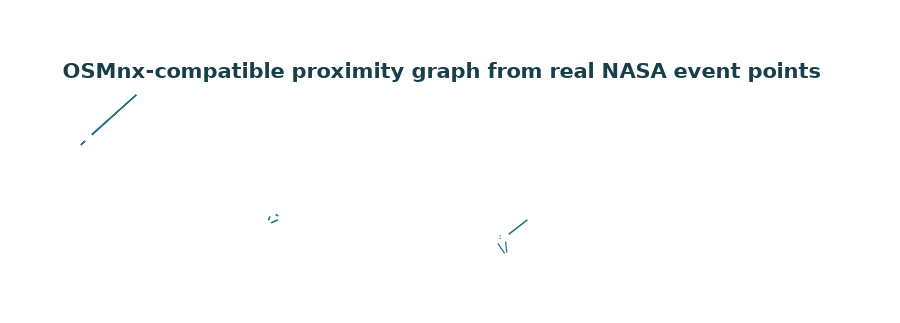

In [17]:
# OSMnx output from real NASA event coordinates, plus an optional live OSM route.
import osmnx as ox
import networkx as nx
from shapely.geometry import LineString
sample = gdf.drop_duplicates("event_id").head(18).reset_index(drop=True)
event_graph = nx.MultiDiGraph(crs="EPSG:4326")
for i, row in sample.iterrows():
    event_graph.add_node(i, x=float(row.longitude), y=float(row.latitude), title=row.title)
coords = sample[["longitude","latitude"]].to_numpy()
for i in range(len(sample)):
    distances = np.sum((coords - coords[i])**2, axis=1)
    for j in np.argsort(distances)[1:3]:
        line = LineString([coords[i], coords[j]])
        event_graph.add_edge(i, int(j), key=0, length=float(line.length), geometry=line)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(event_graph)
fig, ax = ox.plot_graph(event_graph, node_size=28, edge_color=TEAL, edge_linewidth=.7,
                        bgcolor="white", show=False, close=False)
ax.set_title("OSMnx-compatible proximity graph from real NASA event points", loc="left", color=NAVY, fontweight="bold")
fig.savefig(OUTPUT / "eonet_osmnx_compatible_graph.png", bbox_inches="tight")
plt.show()
print("This is a derived event-proximity graph, not an OpenStreetMap street network.")

RUN_LIVE_OSM = False
if RUN_LIVE_OSM:
    place = "Jinxi Ancient Town, Kunshan, Jiangsu, China"
    street_graph = ox.graph_from_place(place, network_type="walk", simplify=True)
    print(f"Live OpenStreetMap retrieval succeeded: {len(street_graph)} nodes.")
else:
    print("Optional live Jinxi OSM retrieval is off for reproducible execution. Set RUN_LIVE_OSM=True to run it.")

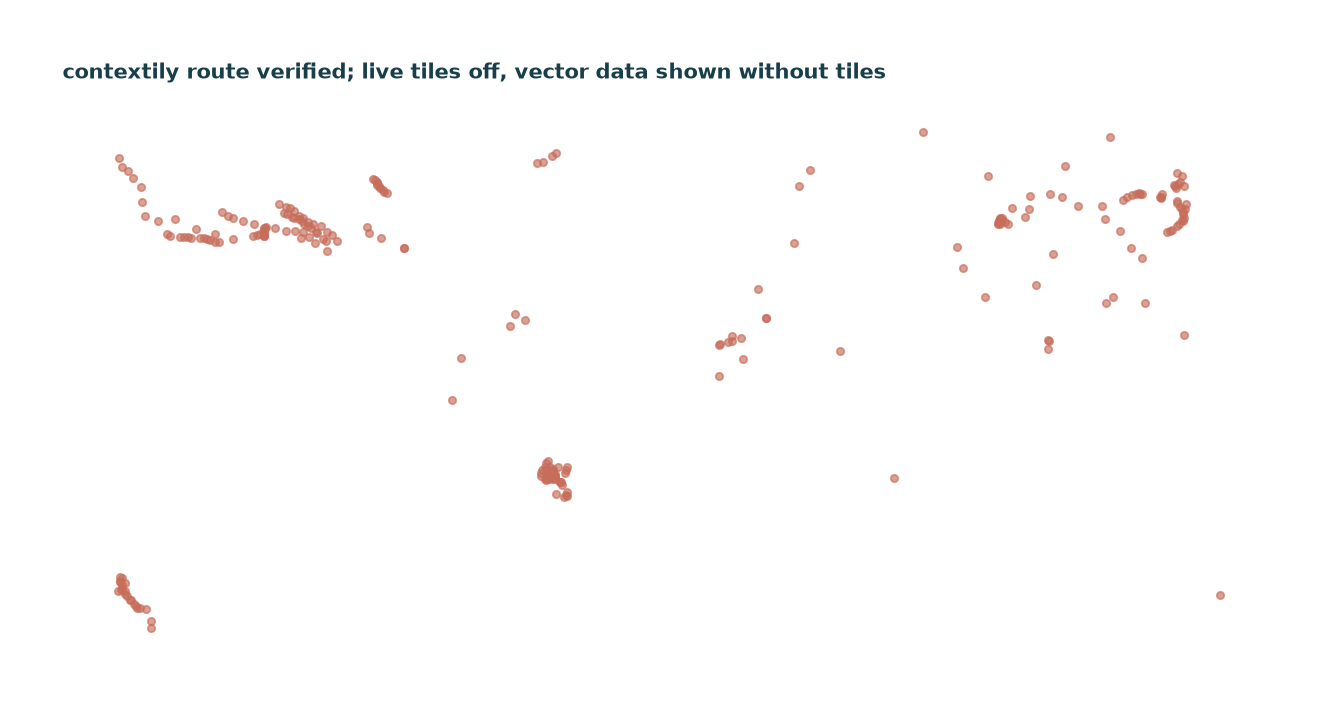

In [18]:
# contextily adds web tiles only when service access is available; the data layer remains usable without them.
import contextily as ctx
local = gdf.to_crs(3857).head(250)
fig, ax = plt.subplots(figsize=(10,6))
local.plot(ax=ax, color=CORAL, markersize=18, alpha=.65)
RUN_LIVE_BASEMAP = False
try:
    if not RUN_LIVE_BASEMAP:
        raise RuntimeError("Live tiles disabled for reproducible execution")
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, attribution_size=6)
    status = "Live basemap tiles added"
except Exception:
    status = "contextily route verified; live tiles off, vector data shown without tiles"
ax.set_title(status, loc="left", color=NAVY, fontweight="bold")
ax.set_axis_off(); fig.tight_layout(); plt.show()

## Human centered spatiotemporal intelligence

Human-centered work adds more than a new model:

- **Experience:** place includes perception, emotion, cognition, memory, access, and cultural meaning.
- **Agency:** users should be able to inspect sources, uncertainty, alternatives, and consequences.
- **Justice:** ask who is visible, who is missing, who bears risk, and whether aggregation or location traces expose people.
- **Situated validation:** test the representation in the place, task, and social setting where it will be used.
- **Model accountability:** spatial embeddings and GeoAI predictions require geographic-bias, transfer, provenance, and uncertainty checks.

The fieldwork card therefore separates **observation**, **interpretation**, **missing evidence**, **permission**, and **design consequence**.

## Frontier project gallery and transfer questions

- **NASA Worldview and EONET:** What does near-real-time exploration support, and what human-impact evidence remains absent? https://worldview.earthdata.nasa.gov/ and https://eonet.gsfc.nasa.gov/
- **Google Earth Engine and AlphaEarth Foundations:** How can learned satellite embeddings support change detection, and how will users understand a 64-dimensional representation? https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL
- **IEEE GRSS Data Fusion Contest:** How should multimodal SAR and optical evidence be fused and uncertainty communicated? https://www.grss-ieee.org/community/technical-committees/2025-ieee-grss-data-fusion-contest/
- **TorchGeo and TorchSpatial:** Which sampling, representation, geographic-bias, and reproducibility decisions belong in the interface? https://torchgeo.readthedocs.io/ and https://github.com/seai-lab/TorchSpatial
- **SpaceNet and VisDrone:** What can satellite and drone benchmarks detect, and what surveillance, labeling, and transfer risks follow? https://spacenet.ai/ and https://github.com/VisDrone/VisDrone-Dataset
- **Digital Earth Africa:** How can analysis-ready Earth observation become decision-ready through local priorities and capacity? https://digitalearthafrica.org/

## Final-project transfer task

Add one paragraph and one figure to your team claim:

- **Spatiotemporal question and user:** What decision occurs where and when?
- **Idiom:** map, space-time cube, trajectory, small multiples, animation, linked map and timeline, raster, or situated view. Why?
- **Algorithm:** projection, aggregation, interpolation, routing, clustering, change detection, spatial statistic, or representation learning. What assumption matters?
- **Human-centered safeguard:** privacy, geographic bias, uncertainty, accessibility, consent, local knowledge, or ability to contest.
- **MVP addition:** What will be demonstrable in Week 5 and tested in Week 6?

**Required submission evidence:** output, caption with claim and boundary, code, source and license note, spatial and temporal coverage, accessible fallback, and one next test.

## Selected publications

- Shin et al. *The Reality of the Situation: A Survey of Situated Analytics*. IEEE TVCG 30(8), 2024, 5147-5164. https://doi.org/10.1109/TVCG.2023.3285546
- Mai et al. *Towards the Next Generation of Geospatial Artificial Intelligence*. International Journal of Applied Earth Observation and Geoinformation 136, 2025. https://doi.org/10.1016/j.jag.2025.104368
- Ye et al. *Human-centered GeoAI foundation models: where GeoAI meets human dynamics*. Urban Informatics 4, 2, 2025. https://doi.org/10.1007/s44212-025-00067-x
- Kang. *Human-Centered Geospatial Data Science*. International Encyclopedia of Geography, 2025. https://doi.org/10.1002/9781118786352.wbieg2209
- Wu et al. *TorchSpatial: A Location Encoding Framework and Benchmark for Spatial Representation Learning*. NeurIPS Datasets and Benchmarks, 2024. https://arxiv.org/abs/2406.15658
- Manvi et al. *GeoLLM: Extracting Geospatial Knowledge from Large Language Models*. ICLR 2024. https://openreview.net/forum?id=TqL2xBwXP3

## Atlas Studio enhancement · four levels, four validation tests

**Domain → Data/Task → Idiom → Algorithm. Validation belongs at every level; it is not a fifth level.**

Keep the original package experiments below/above as optional depth. The new cells connect them to a real communication or community question. The self-contained snapshots are embedded, so downloading just this notebook is enough for the new data examples. No live API call is required.

| Level | Decision | Validation evidence | Project addition |
|---|---|---|---|
| Domain | Audience/community, need and task | Observation/interview; whose need is not established? | Refined shared research question |
| Data/Task | Unit, relationship, time, coverage | Source record checks; domain-informed abstraction review | Data dictionary and provenance |
| Idiom | Basic baseline + advanced view | Observed task comparison, errors, accessibility | Justified linked-view design |
| Algorithm | Transformation, parameters and computation | Tests, reproducibility, sensitivity | Working MVP and evidence record |

**Week 4 → Week 5 → Week 6 → Week 7:** individual evidence and Reflection 1 → proposal plus MVP → demonstration/user study/feedback/response (15%) → future-roadmap roundtable (5%) and Reflection 2. These 15% and 5% are the split of the existing 20% component, not extra grading weight.

### Human-centered spatial–temporal intelligence for digital humanities

**Domain:** An archive or community heritage team wants to understand recognition over time and ask which stories are absent. Official data cannot answer community value, accessibility, consent or lived experience by itself.

**Data/Task:** 1,457 unique NYC individual-landmark designation IDs. Source had 2,065 building records; 74 missing/invalid coordinate/date records were excluded, then IDs deduplicated. We retain the first valid building coordinate and count of remaining building records. A designation date is **not** a construction date.

Source: https://data.cityofnewyork.us/Housing-Development/Designated-and-Calendared-Buildings-and-Sites/ncre-qhxs. Retrieved 2026-09-14. Public metadata under NYC Open Data terms; no photographs copied. These NYC data do not establish Jinxi community needs.


In [1]:
import base64, gzip, json
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from IPython.display import display
heritage_records = json.loads(gzip.decompress(base64.b64decode('...')))
heritage_df = pd.DataFrame(heritage_records)
heritage_df['date'] = pd.to_datetime(heritage_df['date'], errors='raise')
assert heritage_df['id'].is_unique
assert heritage_df.lon.between(-180,180).all() and heritage_df.lat.between(-90,90).all()
heritage_geo = gpd.GeoDataFrame(heritage_df, geometry=gpd.points_from_xy(heritage_df.lon,heritage_df.lat), crs='EPSG:4326')
print(len(heritage_geo), 'unique designation IDs; coordinate system:', heritage_geo.crs)
display(heritage_df[['title','group','date','buildingRecords','url']].head(5))


1457 unique designation IDs; coordinate system: EPSG:4326


,title,group,date,buildingRecords,url
0,Pieter Claesen Wyckoff House,Brooklyn,1965-10-14,1,https://data.cityofnewyork.us/resource/ncre-qh...
1,"Commandant's House, Quarters A, Brooklyn Navy ...",Brooklyn,1965-10-14,1,https://data.cityofnewyork.us/resource/ncre-qh...
2,"Old United States Naval Hospital, Brooklyn Nav...",Brooklyn,1965-10-14,1,https://data.cityofnewyork.us/resource/ncre-qh...
3,Boat House on the Lullwater of the Lake in Pro...,Brooklyn,1965-10-14,1,https://data.cityofnewyork.us/resource/ncre-qh...
4,Kingsland Homestead,Queens,1965-10-14,1,https://data.cityofnewyork.us/resource/ncre-qh...


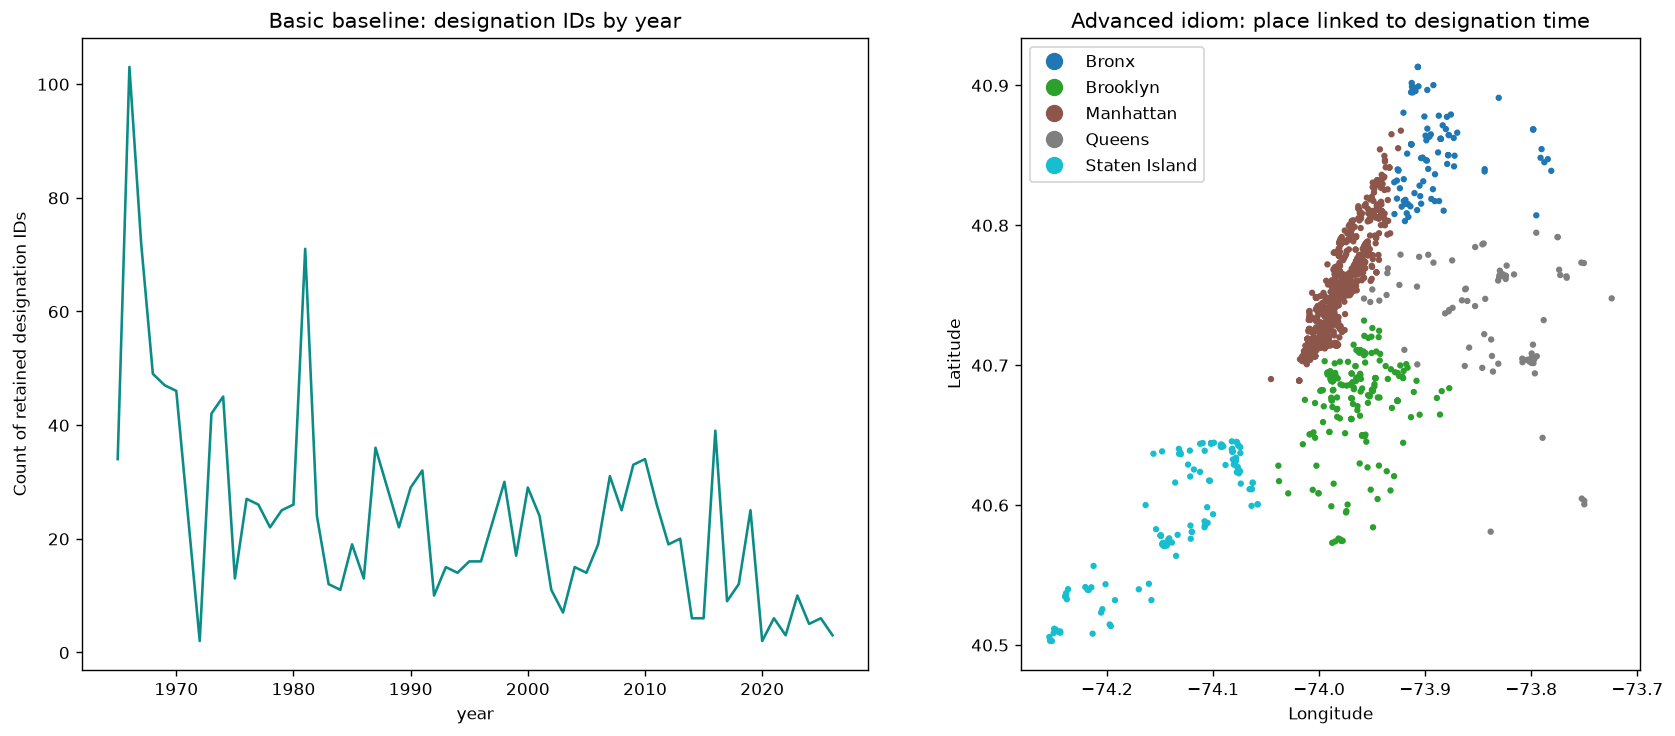

In [2]:
# A linked basic timeline and spatial view: all retained records, same unit.
fig, axes = plt.subplots(1,2, figsize=(14,6))
heritage_df.groupby('year').size().plot(ax=axes[0], color='#0b8c86')
axes[0].set_title('Basic baseline: designation IDs by year')
axes[0].set_ylabel('Count of retained designation IDs')
heritage_geo.plot(ax=axes[1], column='group', markersize=7, legend=True, cmap='tab10')
axes[1].set_title('Advanced idiom: place linked to designation time')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
plt.tight_layout(); plt.show()


In [3]:
# Configurable temporal comparison; this is not a community-impact test.
start_year, end_year, selected_borough = 1965, 1980, 'Brooklyn'
chosen = heritage_geo[heritage_geo.year.between(start_year,end_year) & (heritage_geo.group==selected_borough)]
assert len(chosen) <= len(heritage_geo)
assert chosen.year.between(start_year,end_year).all()
print('Filtered records:', len(chosen), '|', selected_borough, start_year, 'through', end_year)
display(chosen[['title','date','url']].head(8))
# If you calculate distance or area, select a suitable projected CRS first.
# Counts on this map do not establish preservation quality or cultural worth.


Filtered records: 84 | Brooklyn 1965 through 1980


,title,date,url
0,Pieter Claesen Wyckoff House,1965-10-14,https://data.cityofnewyork.us/resource/ncre-qh...
1,"Commandant's House, Quarters A, Brooklyn Navy ...",1965-10-14,https://data.cityofnewyork.us/resource/ncre-qh...
2,"Old United States Naval Hospital, Brooklyn Nav...",1965-10-14,https://data.cityofnewyork.us/resource/ncre-qh...
3,Boat House on the Lullwater of the Lake in Pro...,1965-10-14,https://data.cityofnewyork.us/resource/ncre-qh...
105,Main Brooklyn Post Office,1966-07-19,https://data.cityofnewyork.us/resource/ncre-qh...
106,Brooklyn Borough Hall,1966-04-19,https://data.cityofnewyork.us/resource/ncre-qh...
107,Old Brooklyn Fire Headquarters,1966-04-19,https://data.cityofnewyork.us/resource/ncre-qh...
108,Green-Wood Cemetery Gates,1966-04-19,https://data.cityofnewyork.us/resource/ncre-qh...


### Transfer to fieldwork and human-centered GeoAI

- Before Jinxi fieldwork: define one observable question, one inference to avoid, whose permission is required, and which details must not be published.
- After fieldwork: separate observed evidence, interpretation and a question still requiring community input. Do not infer consent from a public location.
- Explain what a basic timeline, a relationship network and a place/time view each add to the same group question.
- Test a 2D map/timeline against the optional 3D space–time cube. Height means year—not importance. Record actual task success and misreadings.
- Advanced frontier: NASA Prithvi, Earth Engine, IEEE GRSS SAR temporal storytelling, Cesium or OpenDroneMap. Choose one only if the research question requires it; verify access, data rights, ground truth, generalization and human oversight. None is evidence that the browser app performs AI inference.
- Week 6: log demonstration, peer feedback and responses. Week 7: propose one next model/data/user validation that could change the result; distinguish completed work from the roadmap.
